In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from main import GuassianDiffusion
from unets import UNet
from data import get_metadata

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Testing on: {device}")

Testing on: cpu


In [24]:
# Initialize diffusion with T=1000
diffusion = GuassianDiffusion(timesteps=1000, device=device)

print(f"Beta shape: {diffusion.scalars.beta.shape}") #  [1000] [cite: 75]
print(f"Alpha_bar (start): {diffusion.scalars.alpha_bar[0]:.4f}") # Close to 1.0 [cite: 102]
print(f"Alpha_bar (end): {diffusion.scalars.alpha_bar[-1]:.4f}")   # Close to 0.0 [cite: 83]

# Test Forward Process: Jump to timestep t=500
dummy_img = torch.randn(1, 3, 64, 64).to(device) # clean image [cite: 181]
t = torch.tensor([500]).to(device)

xt, eps = diffusion.sample_from_forward_process(dummy_img, t)

print(f"Noisy image xt shape: {xt.shape}") # Expect [1, 3, 64, 64] [cite: 105]
print(f"Injected noise eps shape: {eps.shape}") # Expect [1, 3, 64, 64] [cite: 104]
print(diffusion.scalars.keys())

Beta shape: torch.Size([1000])
Alpha_bar (start): 1.0000
Alpha_bar (end): 0.0000
Noisy image xt shape: torch.Size([1, 3, 64, 64])
Injected noise eps shape: torch.Size([1, 3, 64, 64])
dict_keys(['beta', 'beta_log', 'alpha', 'alpha_bar', 'beta_tilde', 'beta_tilde_log'])


In [25]:
# Get metadata for Oxford Flowers
metadata = get_metadata("flowers") # [cite: 46, 162]

# Initialize the UNet specifically for 64x64 flowers
# arch is defined in unets.py; using 102 classes [cite: 162]
model = UNet(
    image_size=64, 
    in_channels=3, 
    out_channels=3, 
    num_classes=102
).to(device)

# Simulate Inputs
xt_batch = torch.randn(8, 3, 64, 64).to(device) # Batch of 8 noisy images [cite: 181, 253]
t_batch = torch.randint(0, 1000, (8,)).to(device) # Random timesteps [cite: 386]
y_batch = torch.randint(0, 102, (8,)).to(device) # Random flower classes [cite: 239]

# Forward Pass (Noise Prediction)
with torch.no_grad():
    pred_noise = model(xt_batch, t_batch, y=y_batch)

print(f"Model Input shape: {xt_batch.shape}")
print(f"Model Output (Predicted Noise) shape: {pred_noise.shape}") # Must match Input [cite: 140, 271]

Model Input shape: torch.Size([8, 3, 64, 64])
Model Output (Predicted Noise) shape: torch.Size([8, 3, 64, 64])


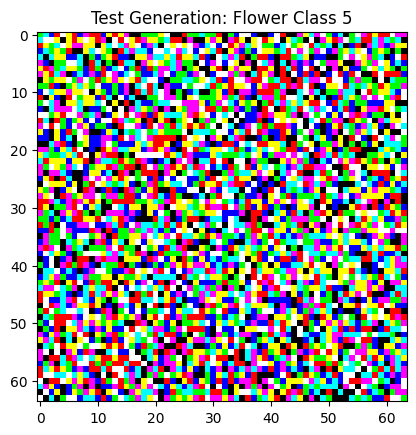

Final Output Dimension: (64, 64, 3)


In [26]:
# Start with pure Gaussian noise [cite: 33, 125]
x_T = torch.randn(1, 3, 64, 64).to(device) 

# Generate a specific flower (e.g., class 5)
specific_y = torch.tensor([5]).to(device)

# Use DDIM for efficiency (250 steps) [cite: 449, 450]
generated_tensor = diffusion.sample_from_reverse_process(
    model=model,
    xT=x_T,
    timesteps=250,
    model_kwargs={"y": specific_y},
    ddim=True
)

# Rescale from [-1, 1] to [0, 1] for visualization
final_img = (generated_tensor + 1) / 2
final_img = final_img.clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()[0]

plt.imshow(final_img)
plt.title(f"Test Generation: Flower Class {specific_y.item()}")
plt.show()

print(f"Final Output Dimension: {final_img.shape}") # Expect [64, 64, 3] [cite: 22, 255]

In [27]:
t = torch.randint(diffusion.timesteps, (64,), dtype=torch.int64).to(
            'cpu'
        )
t

tensor([374, 731, 264, 467, 814, 238, 775, 881, 792, 906, 761, 653, 513, 979,
        363, 228, 428, 672, 664,  83, 749, 661, 452, 106, 364, 264, 683,  22,
        244, 682, 583, 770, 282, 721, 783, 585, 189,  86, 533, 850, 914, 433,
        935, 218, 341, 900, 429, 640, 722,  24,  23, 957, 713, 767, 760, 939,
        629, 732, 241, 224,  23, 315, 477, 247])